# Customer Segmentation Analysis for Enhanced Marketing Strategies

## Customer Segmentation

### Choosing the optimal number of customer segments/clusters using the Elbow Method

In [56]:
data = df.copy()

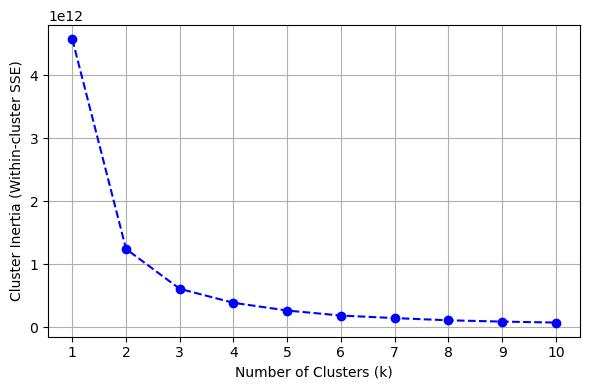

In [58]:
from sklearn.cluster import KMeans

# Elbow method using inertias
inertias = []  # To store the inertia for each number of clusters

# Loop over a range of cluster numbers (1 to 10) and calculate inertia
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(data)  # Fitting KMeans to the data
    inertias.append(km.inertia_)  # Storing the inertia value

# Plotting the elbow plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cluster Inertia (Within-cluster SSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()


It looks like the "elbow" in the plot appears to be at k = 3, suggesting that the optimal number of clusters is 3.

**KMeans++**

In [63]:
# Apply KMeans++ with 3 clusters
km_plus = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=0)
y_km_plus = km_plus.fit_predict(data)

# Display cluster centers and customer counts
print("KMeans++ Cluster Centers:\n", km_plus.cluster_centers_)
print("Customer counts in each cluster:\n", pd.Series(y_km_plus).value_counts())

KMeans++ Cluster Centers:
 [[7.38406659e-01 2.77051130e-01 1.54458977e+00 1.25564804e+00
  1.04518430e+00 9.24439893e+04 3.24708680e+01]
 [2.05949657e-01 4.82837529e-01 2.95881007e+00 1.78489703e+00
  1.87414188e+00 2.09584346e+05 5.47940503e+01]
 [3.43490305e-01 7.93628809e-01 1.13850416e+00 4.34903047e-01
  9.61218837e-01 1.38114065e+05 3.94265928e+01]]
Customer counts in each cluster:
 0    841
2    722
1    437
Name: count, dtype: int64


In [100]:
variables = ['Gender', 'Marital Status', 'Education', 'Settlement Size', 'Occupation', 'Income', 'Age']

# Cluster centers from KMeans++ (3 clusters)
cluster_centers = km_plus.cluster_centers_

# Convert the cluster centers into a DataFrame
cluster_centers_df = pd.DataFrame(cluster_centers, columns=variables)

# Get customer counts for each cluster
customer_counts = pd.Series(y_km_plus).value_counts()

# Add customer counts as a new row to the DataFrame
cluster_centers_df['Customer Count'] = customer_counts.values

# Display the final table with cluster centers and customer counts
formatted_cluster_centers = cluster_centers_df.T
formatted_cluster_centers.columns = [f"Cluster {i}" for i in range(cluster_centers.shape[0])]

print("\nTable of KMeans++ Clustering Cluster Centers and Customer Counts for each cluster\n")
print(formatted_cluster_centers)



Table of KMeans++ Clustering Cluster Centers and Customer Counts for each cluster:

                    Cluster 0      Cluster 1      Cluster 2
Gender               0.738407       0.205950       0.343490
Marital Status       0.277051       0.482838       0.793629
Education            1.544590       2.958810       1.138504
Settlement Size      1.255648       1.784897       0.434903
Occupation           1.045184       1.874142       0.961219
Income           92443.989298  209584.345538  138114.065097
Age                 32.470868      54.794050      39.426593
Customer Count     841.000000     722.000000     437.000000


**Table of KMeans++ Clustering Cluster Centers and Customer Counts:**
||Gender|Marital Status|Education|Settlement Size|Occupation|Income|Age|Customer Count|
| ---| --- | --- | --- | --- | --- | --- |--- |--- |
| Cluster 0 | 0.738 |0.277|1.544| 1.256|1.045|92443.989|32.470| 841
| Cluster 1 | 0.206 |0.483|2.959| 1.785|1.874|209584.345|54.794| 722
| Cluster 2 | 0.343 |0.794|1.138| 0.435|0.961|138114.065|39.426| 437

**Interpretation of Clusters:**
- Cluster 0 (841 customers): This cluster represents younger (with an average age of 32.47 years), primarily single, lower-income females (\$92,444 average) with high school education, mostly living in mid-sized cities, and working in skilled or unskilled occupations.
- Cluster 1 (722 customers): This cluster consists of older (54.79 years old average), highly educated males in managerial or highly skilled positions, living in large cities, with very high incomes (at \$209,584 average). 
- Cluster 2 (437 customers): This cluster represents middle-aged (average 39.43 years), primarily non-single, high-school educated females, working in skilled positions, living in smaller cities, with moderate incomes (\$138,114 average).


**Agglomerative Clustering**

In [90]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(n_clusters=3)
y_agg = agg_clustering.fit_predict(data)

data['Cluster'] = y_agg

# Calculate the mean values for each cluster (to simulate cluster centers)
cluster_centers_agg = data.groupby('Cluster').mean()

# Get customer counts for each cluster
customer_counts_agg = data['Cluster'].value_counts().sort_index()

# Add customer counts as a new column to the cluster centers DataFrame
cluster_centers_agg['Customer Count'] = customer_counts_agg.values

# Rename index to represent clusters
cluster_centers_agg.index = [f'Cluster {i}' for i in range(cluster_centers_agg.shape[0])]

# Display the final table
print("\nAgglomerative Clustering Cluster Centers and Customer Counts:\n")
print(cluster_centers_agg)



Agglomerative Clustering Cluster Centers and Customer Counts:

             Gender  Marital Status  Education  Settlement Size  Occupation  \
Cluster 0  0.683000        0.366000   1.461000         1.199000    1.023000   
Cluster 1  0.213483        0.480899   2.946067         1.775281    1.867416   
Cluster 2  0.326126        0.787387   1.156757         0.290090    0.969369   

                  Income        Age  Customer Count  
Cluster 0   96714.334000  33.178000            1000  
Cluster 1  208930.667416  54.626966             445  
Cluster 2  142997.527928  40.057658             555  


**Table of Agglomerative Clustering Cluster Centers and Customer Counts:**
||Gender|Marital Status|Education|Settlement Size|Occupation|Income|Age|Customer Count|
| ---| --- | --- | --- | --- | --- | --- |--- |--- |
| Cluster 0 | 0.683 |0.366|1.461| 1.199|1.023|96714.334|33.178| 1000
| Cluster 1 | 0.213 |0.481|2.946| 1.775|1.867|208930.667|54.627| 445
| Cluster 2 | 0.326 |0.787|1.156| 0.290|0.969|142997.528|40.058| 555

**Interpretation of Clusters:**
- Cluster 0 (1000 customers): This cluster represents younger (with an average age of 33.18 years), single, mainly female customers with high school education, living in mid-sized cities, and working in skilled occupations with lower incomes (\$96,714 average).
- Cluster 1 (445 customers): This cluster consists of older (54.63 years old average), highly educated males in highly skilled or managerial roles, living in larger cities with high incomes (average \$208,931).
- Cluster 2 (555 customers): This cluster represents middle-aged (with an average age of 40.06 years), non-single, high-school educated females living in smaller cities, working in skilled jobs with moderate incomes (\$142,998 average).

